In [2]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import sys
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
import pickle

sys.path.insert(0, 'src')
from grn import grn

In [3]:
with open("../graph.cfg10.rep1.r2.dout3.din100.seed1001.gpickle", 'rb') as f:
    G = pickle.load(f)

## G2: manually adjusted GRN

In [4]:
# manually adjust GRN hyperparameters in an attempt to build GRN with more non-additive effects
np.random.seed(5)
G2 = grn().add_structure(
    n=256,
    k=1,
    alpha=1e-99,
    beta=0.99,       # 1 - 1/r
    gamma=0.01,      # 1/r
    kappa=10,        # --w
    delta_in=100,
    delta_out=100,
)

G2.simulate_rna(
    s=1e-4,
    dt=1e-2,
    tmax=20000,
    burnin=5000,
    tol=1e-3,
    save=False,
)

array([[4.84649231e-10, 4.18872025e-01, 3.77322668e-03, 1.69880546e-10,
        1.06239300e+00, 3.58549281e-07, 5.00508449e-07, 1.01727610e+00,
        9.22185642e-05, 1.12122699e+00, 2.52883912e-02, 1.08584806e+00,
        1.25280245e-09, 1.20867685e+00, 1.53776463e+00, 1.08056495e-08,
        1.55010171e-04, 1.83459186e-06, 1.09137161e+00, 1.06043472e-09,
        1.08336101e+00, 8.00775265e-03, 1.21524535e+00, 2.25520557e-09,
        9.16532224e-03, 1.34900708e+00, 1.06786693e+00, 8.67781628e-01,
        8.78636767e-02, 1.01295853e+00, 8.87810232e-10, 1.04249830e+00,
        1.02088890e+00, 1.16010403e+00, 3.11985535e-03, 9.27389566e-01,
        1.93303618e-09, 9.72905997e-01, 1.06724803e+00, 1.32670786e-08,
        1.97531781e-03, 1.81200185e-01, 3.82578343e-04, 1.23273126e-06,
        1.06109423e+00, 1.41638243e+00, 1.19667148e+00, 9.15270357e-02,
        1.13071151e+00, 1.03317256e+00, 3.75856888e-07, 1.01290271e+00,
        1.08133226e+00, 1.20993819e+00, 1.05294511e+00, 1.630200

## G3: second manually adjusted GRN

In [5]:
# Same random seed as G2, reset before generating G3
np.random.seed(5)
G3 = grn().add_structure(
    n=256,
    k=1,
    alpha=1e-99,
    beta=0.75,       # 1 - 1/r
    gamma=0.25,      # 1/r
    kappa=10,        # --w
    delta_in=100,
    delta_out=1,
)

G3.simulate_rna(
    s=1e-4,
    dt=1e-2,
    tmax=20000,
    burnin=5000,
    tol=1e-3,
    save=False,
)

array([[0.40134766, 0.52113436, 0.41345122, 0.55423591, 0.24940203,
        0.00824444, 0.7499939 , 0.05158365, 0.34878561, 0.24131589,
        0.10210803, 0.42921168, 0.43213425, 0.17597388, 0.50327465,
        0.0090051 , 0.84216039, 0.43807547, 0.08892712, 0.00517759,
        0.15249503, 0.00826165, 0.03296733, 0.35410256, 0.025503  ,
        0.02003108, 0.62896421, 0.09378358, 0.37294875, 0.01978424,
        0.26145216, 0.52016119, 0.55319635, 0.59044607, 0.34743717,
        0.21467853, 0.80743297, 0.2937654 , 0.07668098, 0.0138034 ,
        0.41741296, 0.0071455 , 0.32524356, 0.38381767, 0.07250683,
        0.44120831, 0.20507611, 0.00378403, 0.0889725 , 0.05392258,
        0.02707397, 0.19675887, 0.96476643, 0.57437545, 0.02445512,
        0.83692191, 0.02542303, 0.48768259, 0.22263909, 0.0725727 ,
        0.06521748, 0.82519536, 0.1272956 , 0.20865251, 0.25144698,
        0.28727185, 0.09699723, 0.21344278, 0.0803279 , 0.04291328,
        0.29524823, 0.35575755, 0.13498879, 0.01

## Original GRN: G

In [6]:
single_ko_expression = np.zeros((G.n, G.n))
single_ko_logfc = np.zeros((G.n, G.n))
single_ko_convergence = {}

for gene in tqdm(range(G.n), desc="Simulating single-gene KOs"):
    
    result = G.ko_nodes(
        genes=[gene],
        stats=("new_rna", 'logfc', 'convergence'),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )
    
    single_ko_expression[gene, :] = result["new_rna"].flatten()
    single_ko_logfc[gene, :] = result["logfc"].flatten()
    single_ko_convergence[gene] = result['convergence']
x_single_ko = np.eye(G.n)
y_single_ko = single_ko_expression

Simulating single-gene KOs:   0%|          | 0/256 [00:00<?, ?it/s]

In [7]:
pairs = list(combinations(range(G.n), 2))

n_jobs = 16

def run_double_ko(pair):
    a, b = pair

    result = G.ko_nodes(
        genes=[a, b],
        stats=("new_rna", "logfc", 'convergence'),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )

    return (
        np.asarray(result["new_rna"]).flatten(),
        np.asarray(result["logfc"]).flatten(),
        np.asarray(result['convergence'])
    )


results = Parallel(
    n_jobs=16,
    pre_dispatch="n_jobs",
    prefer="processes",
    verbose=10,
)(
    delayed(run_double_ko)(pair)
    for pair in pairs
)

double_expression = np.asarray(
    [r[0] for r in results],
    dtype=np.float32
)

double_logfc = np.asarray(
    [r[1] for r in results],
    dtype=np.float32
)
double_convergence = np.asarray(
    [r[2] for r in results],
    dtype=np.float32
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 tasks      | elapsed:    4.0s
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    4.0s
[Parallel(n_jobs=16)]: Done  16 tasks      | elapsed:    4.0s
[Parallel(n_jobs=16)]: Done  25 tasks      | elapsed:    4.4s
[Parallel(n_jobs=16)]: Done  34 tasks      | elapsed:    4.7s
[Parallel(n_jobs=16)]: Done  45 tasks      | elapsed:    4.8s
[Parallel(n_jobs=16)]: Done  56 tasks      | elapsed:    5.0s
[Parallel(n_jobs=16)]: Done  69 tasks      | elapsed:    5.3s
[Parallel(n_jobs=16)]: Done  82 tasks      | elapsed:    5.5s
[Parallel(n_jobs=16)]: Done  97 tasks      | elapsed:    5.7s
[Parallel(n_jobs=16)]: Done 112 tasks      | elapsed:    6.0s
[Parallel(n_jobs=16)]: Done 129 tasks      | elapsed:    6.3s
[Parallel(n_jobs=16)]: Done 146 tasks      | elapsed:    6.6s
[Parallel(n_jobs=16)]: Done 165 tasks      | elapsed:    6.9s
[Parallel(n_jobs=16)]: Done 184 tasks      | elapsed:  

In [8]:
pairs = np.asarray(pairs, dtype=int)
# Extract the single KO logFC values for genes A and B in each pair
single_a = single_ko_logfc[pairs[:, 0], :]
single_b = single_ko_logfc[pairs[:, 1], :]

# Calculate the expected additive effect
expected_additive = single_a + single_b

# The nonadditiveness (interaction residuals) is the difference 
# between the actual double KO logFC and the additive expectation
interaction_residuals = double_logfc - expected_additive

# Flatten into a 1D array to prepare for histograms/quantiles
errors = interaction_residuals.ravel()

# Filter out any infinite values (in case zero expression produced infinite logFC)
errors = errors[np.isfinite(errors)]

# Verification prints matching your V3 format
print("double KO:", double_logfc.shape)
print("additive expectation:", expected_additive.shape)
print("interaction residuals:", interaction_residuals.shape)
print("Number of valid residuals:", len(errors))

double KO: (32640, 256)
additive expectation: (32640, 256)
interaction residuals: (32640, 256)
Number of valid residuals: 8355840


## G2: single and double KOs

In [9]:
single_ko_expression_G2 = np.zeros((G2.n, G2.n))
single_ko_logfc_G2 = np.zeros((G2.n, G2.n))
single_ko_convergence_G2 = {}

for gene in tqdm(range(G2.n), desc="Simulating single-gene KOs"):
    
    result = G2.ko_nodes(
        genes=[gene],
        stats=("new_rna", 'logfc', 'convergence'),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )
    
    single_ko_expression_G2[gene, :] = result["new_rna"].flatten()
    single_ko_logfc_G2[gene, :] = result["logfc"].flatten()
    single_ko_convergence_G2[gene] = result['convergence']
x_single_ko_G2 = np.eye(G2.n)
y_single_ko_G2 = single_ko_expression_G2

Simulating single-gene KOs:   0%|          | 0/256 [00:00<?, ?it/s]

In [ ]:
pairs = list(combinations(range(G2.n), 2))

n_jobs = 16

def run_double_ko_G2(pair):
    a, b = pair

    result = G2.ko_nodes(
        genes=[a, b],
        stats=("new_rna", "logfc", 'convergence'),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )

    return (
        np.asarray(result["new_rna"]).flatten(),
        np.asarray(result["logfc"]).flatten(),
        np.asarray(result['convergence'])
    )


results_G2 = Parallel(
    n_jobs=16,
    pre_dispatch="n_jobs",
    prefer="processes",
    verbose=10,
)(
    delayed(run_double_ko_G2)(pair)
    for pair in pairs
)

double_expression_G2 = np.asarray(
    [r[0] for r in results_G2],
    dtype=np.float32
)

double_logfc_G2 = np.asarray(
    [r[1] for r in results_G2],
    dtype=np.float32
)
double_convergence_G2 = np.asarray(
    [r[2] for r in results_G2],
    dtype=np.float32
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 tasks      | elapsed:    0.5s
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.7s
[Parallel(n_jobs=16)]: Done  16 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done  25 tasks      | elapsed:    1.3s
[Parallel(n_jobs=16)]: Done  34 tasks      | elapsed:    1.6s
[Parallel(n_jobs=16)]: Done  45 tasks      | elapsed:    1.9s
[Parallel(n_jobs=16)]: Done  56 tasks      | elapsed:    2.2s
[Parallel(n_jobs=16)]: Done  69 tasks      | elapsed:    2.7s
[Parallel(n_jobs=16)]: Done  82 tasks      | elapsed:    3.1s
[Parallel(n_jobs=16)]: Done  97 tasks      | elapsed:    3.7s
[Parallel(n_jobs=16)]: Done 112 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 129 tasks      | elapsed:    4.8s
[Parallel(n_jobs=16)]: Done 146 tasks      | elapsed:    5.3s
[Parallel(n_jobs=16)]: Done 165 tasks      | elapsed:    6.0s
[Parallel(n_jobs=16)]: Done 184 tasks      | elapsed:  

In [ ]:
pairs = np.asarray(pairs, dtype=int)
# Extract the single KO logFC values for genes A and B in each pair
single_a_G2 = single_ko_logfc_G2[pairs[:, 0], :]
single_b_G2 = single_ko_logfc_G2[pairs[:, 1], :]

# Calculate the expected additive effect
expected_additive_G2 = single_a_G2 + single_b_G2

# The nonadditiveness (interaction residuals) is the difference 
# between the actual double KO logFC and the additive expectation
interaction_residuals_G2 = double_logfc_G2 - expected_additive_G2

# Flatten into a 1D array to prepare for histograms/quantiles
errors_G2 = interaction_residuals_G2.ravel()

# Filter out any infinite values (in case zero expression produced infinite logFC)
errors_G2 = errors_G2[np.isfinite(errors_G2)]

# Verification prints matching your V3 format
print("double KO:", double_logfc_G2.shape)
print("additive expectation:", expected_additive_G2.shape)
print("interaction residuals:", interaction_residuals_G2.shape)
print("Number of valid residuals:", len(errors_G2))

## G3: single and double KOs

In [ ]:
single_ko_expression_G3 = np.zeros((G3.n, G3.n))
single_ko_logfc_G3 = np.zeros((G3.n, G3.n))
single_ko_convergence_G3 = {}

for gene in tqdm(range(G3.n), desc="Simulating single-gene KOs"):
    
    result = G3.ko_nodes(
        genes=[gene],
        stats=("new_rna", 'logfc', 'convergence'),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )
    
    single_ko_expression_G3[gene, :] = result["new_rna"].flatten()
    single_ko_logfc_G3[gene, :] = result["logfc"].flatten()
    single_ko_convergence_G3[gene] = result['convergence']
x_single_ko_G3 = np.eye(G3.n)
y_single_ko_G3 = single_ko_expression_G3

In [13]:
pairs = list(combinations(range(G3.n), 2))

n_jobs = 16

def run_double_ko_G3(pair):
    a, b = pair

    result = G3.ko_nodes(
        genes=[a, b],
        stats=("new_rna", "logfc", 'convergence'),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )

    return (
        np.asarray(result["new_rna"]).flatten(),
        np.asarray(result["logfc"]).flatten(),
        np.asarray(result['convergence'])
    )


results_G3 = Parallel(
    n_jobs=16,
    pre_dispatch="n_jobs",
    prefer="processes",
    verbose=10,
)(
    delayed(run_double_ko_G3)(pair)
    for pair in pairs
)

double_expression_G3 = np.asarray(
    [r[0] for r in results_G3],
    dtype=np.float32
)

double_logfc_G3 = np.asarray(
    [r[1] for r in results_G3],
    dtype=np.float32
)
double_convergence_G3 = np.asarray(
    [r[2] for r in results_G3],
    dtype=np.float32
)

[Parallel(n_jobs=16)]: Done 2797 tasks      | elapsed:   46.7s
[Parallel(n_jobs=16)]: Done 2872 tasks      | elapsed:   47.9s
[Parallel(n_jobs=16)]: Done 2949 tasks      | elapsed:   49.0s
[Parallel(n_jobs=16)]: Done 3026 tasks      | elapsed:   50.2s
[Parallel(n_jobs=16)]: Done 3105 tasks      | elapsed:   51.4s
[Parallel(n_jobs=16)]: Done 3184 tasks      | elapsed:   52.5s
[Parallel(n_jobs=16)]: Done 3265 tasks      | elapsed:   53.8s
[Parallel(n_jobs=16)]: Done 3346 tasks      | elapsed:   55.0s
[Parallel(n_jobs=16)]: Done 3429 tasks      | elapsed:   56.2s
[Parallel(n_jobs=16)]: Done 3512 tasks      | elapsed:   57.5s
[Parallel(n_jobs=16)]: Done 3597 tasks      | elapsed:   58.9s
[Parallel(n_jobs=16)]: Done 3682 tasks      | elapsed:  1.0min
[Parallel(n_jobs=16)]: Done 3769 tasks      | elapsed:  1.0min
[Parallel(n_jobs=16)]: Done 3856 tasks      | elapsed:  1.0min
[Parallel(n_jobs=16)]: Done 3945 tasks      | elapsed:  1.1min
[Parallel(n_jobs=16)]: Done 4034 tasks      | elapsed: 

In [16]:
pairs = np.asarray(pairs, dtype=int)
# Extract the single KO logFC values for genes A and B in each pair
single_a_G3 = single_ko_logfc_G3[pairs[:, 0], :]
single_b_G3 = single_ko_logfc_G3[pairs[:, 1], :]

# Calculate the expected additive effect
expected_additive_G3 = single_a_G3 + single_b_G3

# The nonadditiveness (interaction residuals) is the difference 
# between the actual double KO logFC and the additive expectation
interaction_residuals_G3 = double_logfc_G3 - expected_additive_G3

# Flatten into a 1D array to prepare for histograms/quantiles
errors_G3 = interaction_residuals_G3.ravel()

# Filter out any infinite values (in case zero expression produced infinite logFC)
errors_G3 = errors_G3[np.isfinite(errors_G3)]

# Verification prints matching your V3 format
print("double KO:", double_logfc_G3.shape)
print("additive expectation:", expected_additive_G3.shape)
print("interaction residuals:", interaction_residuals_G3.shape)
print("Number of valid residuals:", len(errors_G3))

double KO: (32640, 256)
additive expectation: (32640, 256)
interaction residuals: (32640, 256)
Number of valid residuals: 8355840


## Overlaid histogram: G, G2, G3

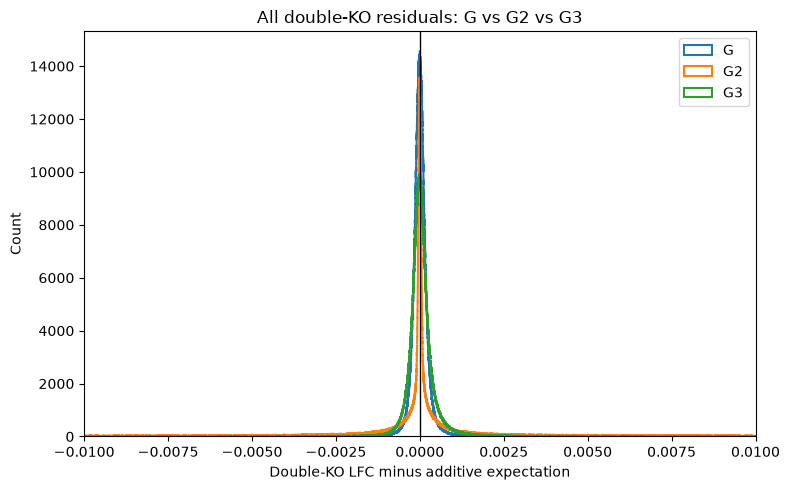

In [19]:
# Shared bins within the plotted range make the histograms comparable.
common_bins = np.linspace(-0.01, 0.01, 30001)  # Original notebook used 30000 bins

plt.figure(figsize=(8, 5))

plt.hist(errors, bins=common_bins, histtype='step', linewidth=1.5, label='G')
plt.hist(errors_G2, bins=common_bins, histtype='step', linewidth=1.5, label='G2')
plt.hist(errors_G3, bins=common_bins, histtype='step', linewidth=1.5, label='G3')

plt.axvline(0, linewidth=1, color='black')
plt.xlim(-0.01, 0.01)

plt.xlabel('Double-KO LFC minus additive expectation')
plt.ylabel('Count')
plt.title('All double-KO residuals: G vs G2 vs G3')
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
from cycler import cycler
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 14,
    'font.family': 'DejaVu Sans',
    'axes.prop_cycle': cycler(color=['black', '#555555', '#888888', '#bbbbbb']),
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black'
})

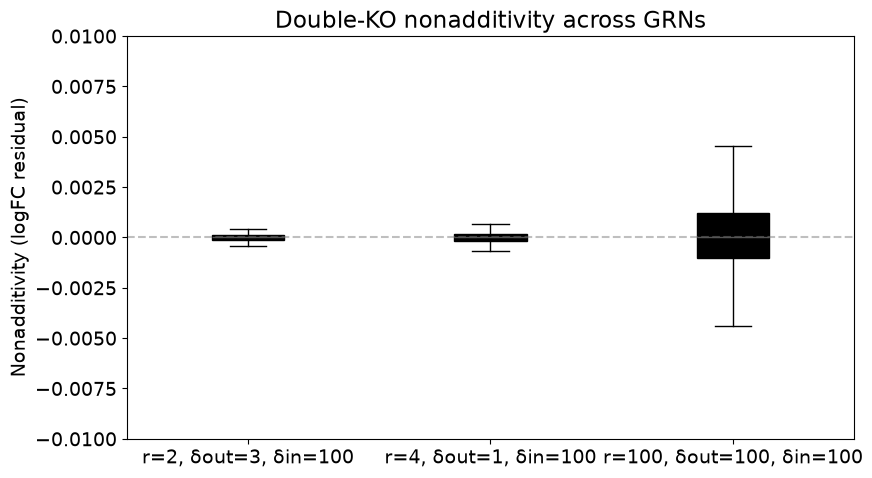

In [22]:
plt.figure(figsize=(9, 5))

plt.boxplot(
    [errors, errors_G3, errors_G2],
    tick_labels=[
        'r=2, δout=3, δin=100',
        'r=4, δout=1, δin=100',
        'r=100, δout=100, δin=100'
    ],
    showfliers=False,
    patch_artist=True
)

plt.ylabel('Nonadditivity (logFC residual)')
plt.title('Double-KO nonadditivity across GRNs')
plt.ylim(-0.01, 0.01)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig(
    'double_KO_nonadditivity_boxplot.png',
    dpi=600,
    bbox_inches='tight'
)
plt.show()

In [21]:
plt.savefig(
    'double_KO_nonadditivity_boxplot.png',
    dpi=600,
    bbox_inches='tight'
)
plt.show()

<Figure size 640x480 with 0 Axes>

In [23]:
import copy
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.linear_model import LinearRegression

device = torch.device('cpu')
mlp_seeds = [2, 3, 4, 5, 6]
max_epochs, batch_size = 300, 256
patience, lr_patience = 40, 12
n_boot = 2000

# Order: G, G3, G2
grn_configs = [
    ('r=2, δout=3, δin=100', G, single_ko_expression, double_expression),
    ('r=4, δout=1, δin=100', G3, single_ko_expression_G3, double_expression_G3),
    ('r=100, δout=100, δin=100', G2, single_ko_expression_G2, double_expression_G2),
]

def make_mlp(n):
    return nn.Sequential(
        nn.Linear(n, 512), nn.GELU(),
        nn.Linear(512, 512), nn.GELU(),
        nn.Linear(512, n)
    ).to(device)

def pearson_from_moments(m, count):
    sx, sy, sxx, syy, sxy = m
    vx = sxx - sx * sx / count
    vy = syy - sy * sy / count
    if vx <= 0 or vy <= 0:
        return 0.0
    return float((sxy - sx * sy / count) / np.sqrt(vx * vy))

benchmark_rows, seed_rows, best_models = [], [], {}

for label, net, single, double in grn_configs:
    print(f'\n=== {label} ===', flush=True)
    n = net.n
    single = np.asarray(single)
    double = np.asarray(double)
    wt = np.asarray(net.rna).reshape(-1)
    pair_ids = np.asarray(list(combinations(range(n), 2)), dtype=np.int32)
    assert single.shape == (n, n) and double.shape == (len(pair_ids), n)

    x_double = np.zeros((len(pair_ids), n), dtype=np.float32)
    x_double[np.arange(len(pair_ids))[:, None], pair_ids] = 1.0

    # Same 50% test, 10% validation, 40% training split
    rng = np.random.default_rng(42)
    indices = rng.permutation(len(pair_ids))
    nt, nv = int(.5 * len(pair_ids)), int(.1 * len(pair_ids))
    test_idx = indices[:nt]
    val_idx = indices[nt:nt + nv]
    train_idx = indices[nt + nv:]

    # Include WT and all single KOs in training
    xtr = np.concatenate([
        np.zeros((1, n), dtype=np.float32),
        np.eye(n, dtype=np.float32),
        x_double[train_idx]
    ])
    ytr = np.concatenate([wt[None, :], single, double[train_idx]])

    xv, yv = x_double[val_idx], double[val_idx]
    xte, yte = x_double[test_idx], double[test_idx]

    mean = ytr.mean(axis=0)
    scale = np.maximum(ytr.std(axis=0), 1e-6)

    xtr_t = torch.as_tensor(xtr, dtype=torch.float32, device=device)
    ytr_t = torch.as_tensor((ytr - mean) / scale, dtype=torch.float32, device=device)
    xv_t = torch.as_tensor(xv, dtype=torch.float32, device=device)

    # Train 5 independent MLPs
    best_val, best_seed, best_state = np.inf, None, None

    for seed in mlp_seeds:
        torch.manual_seed(seed)
        model = make_mlp(n)
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=1e-3, weight_decay=1e-2
        )

        lr, stale, lr_stale = 1e-3, 0, 0
        seed_best, seed_state, seed_epoch = np.inf, None, 0

        for epoch in range(1, max_epochs + 1):
            model.train()
            permutation = torch.randperm(len(xtr_t), device=device)

            for start in range(0, len(xtr_t), batch_size):
                ix = permutation[start:start + batch_size]
                optimizer.zero_grad(set_to_none=True)
                loss = ((model(xtr_t[ix]) - ytr_t[ix]) ** 2).mean()
                loss.backward()
                optimizer.step()

            model.eval()
            with torch.inference_mode():
                val_scaled = np.concatenate([
                    model(chunk).cpu().numpy()
                    for chunk in xv_t.split(1024)
                ])

            val_pred = val_scaled * scale + mean
            val_mse = float(np.mean((val_pred - yv) ** 2))

            if not np.isfinite(val_mse):
                raise FloatingPointError(
                    f'Non-finite loss: {label}, seed={seed}, epoch={epoch}'
                )

            if val_mse < seed_best:
                seed_best, seed_epoch = val_mse, epoch
                seed_state = copy.deepcopy(model.state_dict())
                stale, lr_stale = 0, 0
            else:
                stale += 1
                lr_stale += 1

            if lr_stale >= lr_patience and lr > 1e-5:
                lr = max(1e-5, lr * 0.5)
                for group in optimizer.param_groups:
                    group['lr'] = lr
                lr_stale = 0

            if stale >= patience:
                break

        seed_rows.append({
            'GRN': label,
            'Seed': seed,
            'Best epoch': seed_epoch,
            'Val RMSE': np.sqrt(seed_best)
        })
        print(f'  seed {seed}: val RMSE={np.sqrt(seed_best):.6g} (epoch {seed_epoch})')

        if seed_best < best_val:
            best_val, best_seed, best_state = seed_best, seed, seed_state

    # Restore the best MLP for this GRN
    model = make_mlp(n)
    model.load_state_dict(best_state)
    model.eval()
    best_models[label] = model

    with torch.inference_mode():
        xt = torch.as_tensor(xte, dtype=torch.float32, device=device)
        mlp_scaled = np.concatenate([
            model(chunk).cpu().numpy()
            for chunk in xt.split(1024)
        ])
    mlp_pred = mlp_scaled * scale + mean

    print(f'  selected seed {best_seed} (validation RMSE={best_val**0.5:.6g})')

    # Linear regression baseline
    linear = LinearRegression(fit_intercept=True)
    linear.fit(
        xtr.astype(np.float64),
        ((ytr - mean) / scale).astype(np.float64)
    )
    linear_pred = linear.predict(xte.astype(np.float64)) * scale + mean

    # Additive baseline
    test_pairs = pair_ids[test_idx]
    additive = single[test_pairs[:, 0]] + single[test_pairs[:, 1]] - wt
    baseline_mse = np.mean((additive - yte) ** 2, axis=1)
    true_resid = (yte - additive).astype(np.float64)

    predictions = {
        'Additive': additive,
        'Linear': linear_pred,
        'MLP': mlp_pred
    }

    # Per-pair statistics for bootstrap CIs
    per_model = {}
    for name, pred in predictions.items():
        pair_mse = np.mean((pred - yte) ** 2, axis=1)
        implied = (pred - additive).astype(np.float64)

        moments = np.stack([
            implied.sum(axis=1),
            true_resid.sum(axis=1),
            (implied ** 2).sum(axis=1),
            (true_resid ** 2).sum(axis=1),
            (implied * true_resid).sum(axis=1)
        ], axis=1)

        per_model[name] = (
            pair_mse,
            pair_mse < baseline_mse,
            moments
        )

    # Bootstrap whole double-KO pairs, not individual genes
    boot_rng = np.random.default_rng(9001)
    metric_names = [
        'RMSE', 'Improvement (%)',
        'Residual Pearson', 'Fraction improved'
    ]
    boot = {
        name: {metric: np.empty(n_boot) for metric in metric_names}
        for name in predictions
    }

    count = len(test_idx) * n

    for b in range(n_boot):
        ii = boot_rng.integers(0, len(test_idx), size=len(test_idx))
        baseline = baseline_mse[ii].mean()

        for name, (mse, wins, moments) in per_model.items():
            m = mse[ii].mean()

            boot[name]['RMSE'][b] = np.sqrt(m)
            boot[name]['Improvement (%)'][b] = 100 * (1 - m / baseline)
            boot[name]['Residual Pearson'][b] = pearson_from_moments(
                moments[ii].sum(axis=0), count
            )
            boot[name]['Fraction improved'][b] = wins[ii].mean()

    # Collect point estimates and 95% CIs
    for name, (mse, wins, moments) in per_model.items():
        metrics = {
            'RMSE': np.sqrt(mse.mean()),
            'Improvement (%)': 100 * (1 - mse.mean() / baseline_mse.mean()),
            'Residual Pearson': pearson_from_moments(
                moments.sum(axis=0), count
            ),
            'Fraction improved': wins.mean()
        }

        row = {
            'GRN': label,
            'Model': name,
            'Chosen MLP seed': best_seed
        }

        for metric, estimate in metrics.items():
            row[metric] = estimate
            row[f'{metric} low'], row[f'{metric} high'] = np.quantile(
                boot[name][metric], [.025, .975]
            )

        benchmark_rows.append(row)

benchmark_df = pd.DataFrame(benchmark_rows)
seed_df = pd.DataFrame(seed_rows)

print('\nValidation results by seed:')
display(seed_df)

print('\nTest results (best validation MLP per GRN):')
display(benchmark_df[[
    'GRN', 'Model', 'RMSE', 'Improvement (%)',
    'Residual Pearson', 'Fraction improved'
]].round(4))


=== r=2, δout=3, δin=100 ===
  seed 2: val RMSE=0.000890456 (epoch 291)
  seed 3: val RMSE=0.000887169 (epoch 291)
  seed 4: val RMSE=0.000899533 (epoch 288)
  seed 5: val RMSE=0.000887859 (epoch 299)
  seed 6: val RMSE=0.000890061 (epoch 293)
  selected seed 3 (validation RMSE=0.000887169)

=== r=4, δout=1, δin=100 ===
  seed 2: val RMSE=0.00319823 (epoch 292)
  seed 3: val RMSE=0.00316777 (epoch 297)
  seed 4: val RMSE=0.00319291 (epoch 299)
  seed 5: val RMSE=0.00313497 (epoch 290)
  seed 6: val RMSE=0.00324935 (epoch 292)
  selected seed 5 (validation RMSE=0.00313497)

=== r=100, δout=100, δin=100 ===
  seed 2: val RMSE=0.0671465 (epoch 53)
  seed 3: val RMSE=0.067491 (epoch 48)
  seed 4: val RMSE=0.0671172 (epoch 56)
  seed 5: val RMSE=0.0674446 (epoch 39)
  seed 6: val RMSE=0.0672419 (epoch 44)
  selected seed 4 (validation RMSE=0.0671172)

Validation results by seed:


,GRN,Seed,Best epoch,Val RMSE
0,"r=2, δout=3, δin=100",2,291,0.000890
1,"r=2, δout=3, δin=100",3,291,0.000887
2,"r=2, δout=3, δin=100",4,288,0.000900
3,"r=2, δout=3, δin=100",5,299,0.000888
4,"r=2, δout=3, δin=100",6,293,0.000890
5,"r=4, δout=1, δin=100",2,292,0.003198
6,"r=4, δout=1, δin=100",3,297,0.003168
7,"r=4, δout=1, δin=100",4,299,0.003193
8,"r=4, δout=1, δin=100",5,290,0.003135
9,"r=4, δout=1, δin=100",6,292,0.003249



Test results (best validation MLP per GRN):


,GRN,Model,RMSE,Improvement (%),Residual Pearson,Fraction improved
0,"r=2, δout=3, δin=100",Additive,0.0009,0.0000,0.0000,0.0000
1,"r=2, δout=3, δin=100",Linear,0.0009,-0.5485,0.0420,0.5461
2,"r=2, δout=3, δin=100",MLP,0.0011,-34.5915,0.0619,0.0048
3,"r=4, δout=1, δin=100",Additive,0.0042,0.0000,0.0000,0.0000
4,"r=4, δout=1, δin=100",Linear,0.0042,1.4359,0.1353,0.0548
5,"r=4, δout=1, δin=100",MLP,0.0032,41.7354,0.6477,0.0390
6,"r=100, δout=100, δin=100",Additive,0.0970,0.0000,0.0000,0.0000
7,"r=100, δout=100, δin=100",Linear,0.0832,26.4636,0.5148,0.1610
8,"r=100, δout=100, δin=100",MLP,0.0667,52.6332,0.7268,0.1624


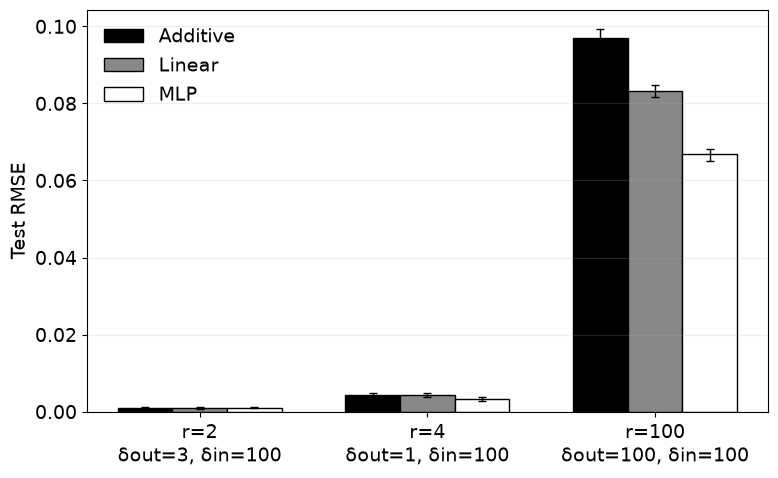

Saved: GRN_benchmark_RMSE.png


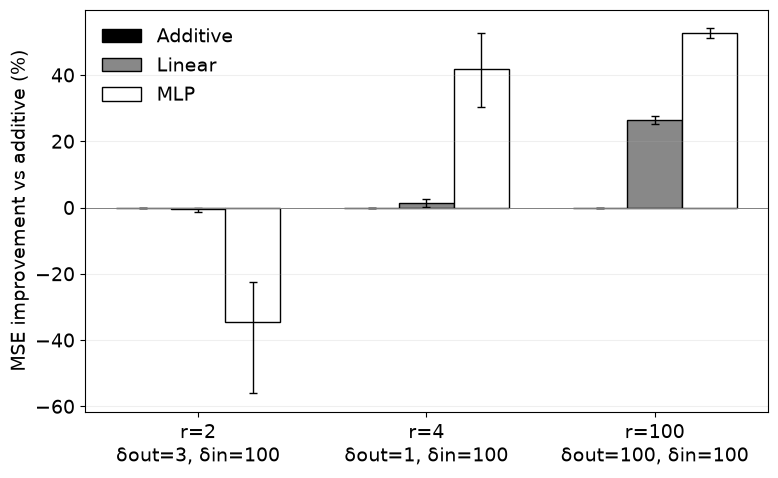

Saved: GRN_benchmark_improvement.png


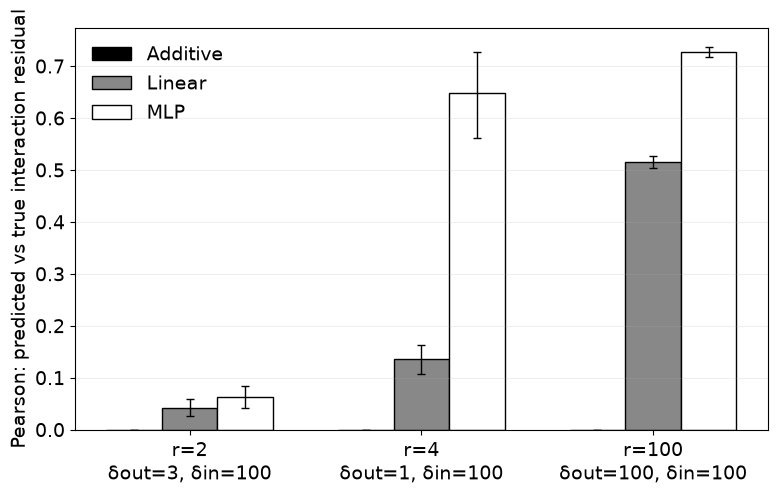

Saved: GRN_benchmark_Pearson.png


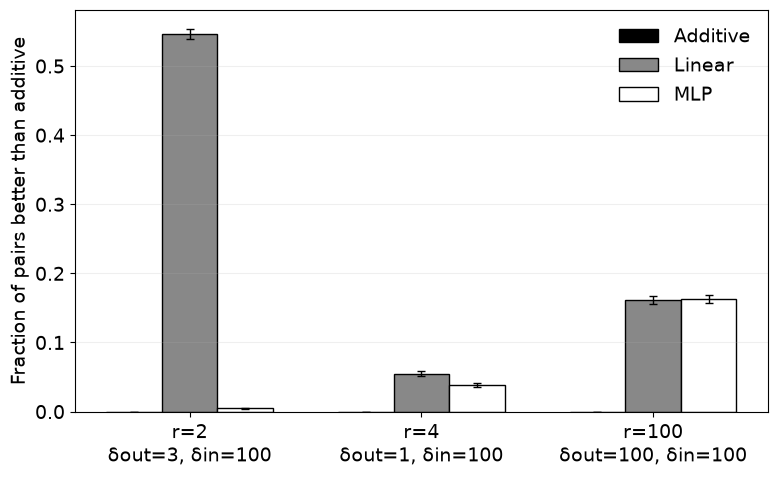

Saved: GRN_benchmark_fraction_improved.png


In [29]:
labels = [x[0] for x in grn_configs]
methods = ['Additive', 'Linear', 'MLP']
colors = ['black', '#888888', 'white']

metrics = [
    ('RMSE', 'Test RMSE', 'GRN_benchmark_RMSE.png'),
    ('Improvement (%)', 'MSE improvement vs additive (%)',
     'GRN_benchmark_improvement.png'),
    ('Residual Pearson', 'Pearson: predicted vs true interaction residual',
     'GRN_benchmark_Pearson.png'),
    ('Fraction improved', 'Fraction of pairs better than additive',
     'GRN_benchmark_fraction_improved.png'),
]

x = np.arange(len(labels))
width = 0.24
indexed = benchmark_df.set_index(['GRN', 'Model'])

for metric, ylabel, filename in metrics:

    fig, ax = plt.subplots(figsize=(8, 5))

    for j, (method, color) in enumerate(zip(methods, colors)):
        rows = indexed.loc[[(lab, method) for lab in labels]]

        values = rows[metric].to_numpy(float)
        low = rows[f'{metric} low'].to_numpy(float)
        high = rows[f'{metric} high'].to_numpy(float)

        yerr = np.vstack([
            np.maximum(values - low, 0),
            np.maximum(high - values, 0)
        ])

        ax.bar(
            x + (j - 1) * width,
            values,
            width,
            label=method,
            yerr=yerr,
            capsize=3,
            color=color,
            error_kw={'linewidth': 1},
            edgecolor='black'
        )

    ax.set_xticks(x)
    ax.set_xticklabels([s.replace(', ', '\n', 1) for s in labels])
    ax.set_ylabel(ylabel)
    ax.axhline(0, color='gray', linewidth=0.7)
    ax.grid(axis='y', alpha=0.2)
    ax.legend(frameon=False)

    fig.tight_layout()

    # Save each graph separately as vector PDF
    fig.savefig(filename, format='png', bbox_inches='tight')

    plt.show()
    plt.close(fig)

    print(f'Saved: {filename}')

r=2, δout=3, δin=100: WL split seed 11
r=2, δout=3, δin=100: WL split seed 22
r=2, δout=3, δin=100: WL split seed 33
r=4, δout=1, δin=100: WL split seed 11
r=4, δout=1, δin=100: WL split seed 22
r=4, δout=1, δin=100: WL split seed 33
r=100, δout=100, δin=100: WL split seed 11
r=100, δout=100, δin=100: WL split seed 22
r=100, δout=100, δin=100: WL split seed 33


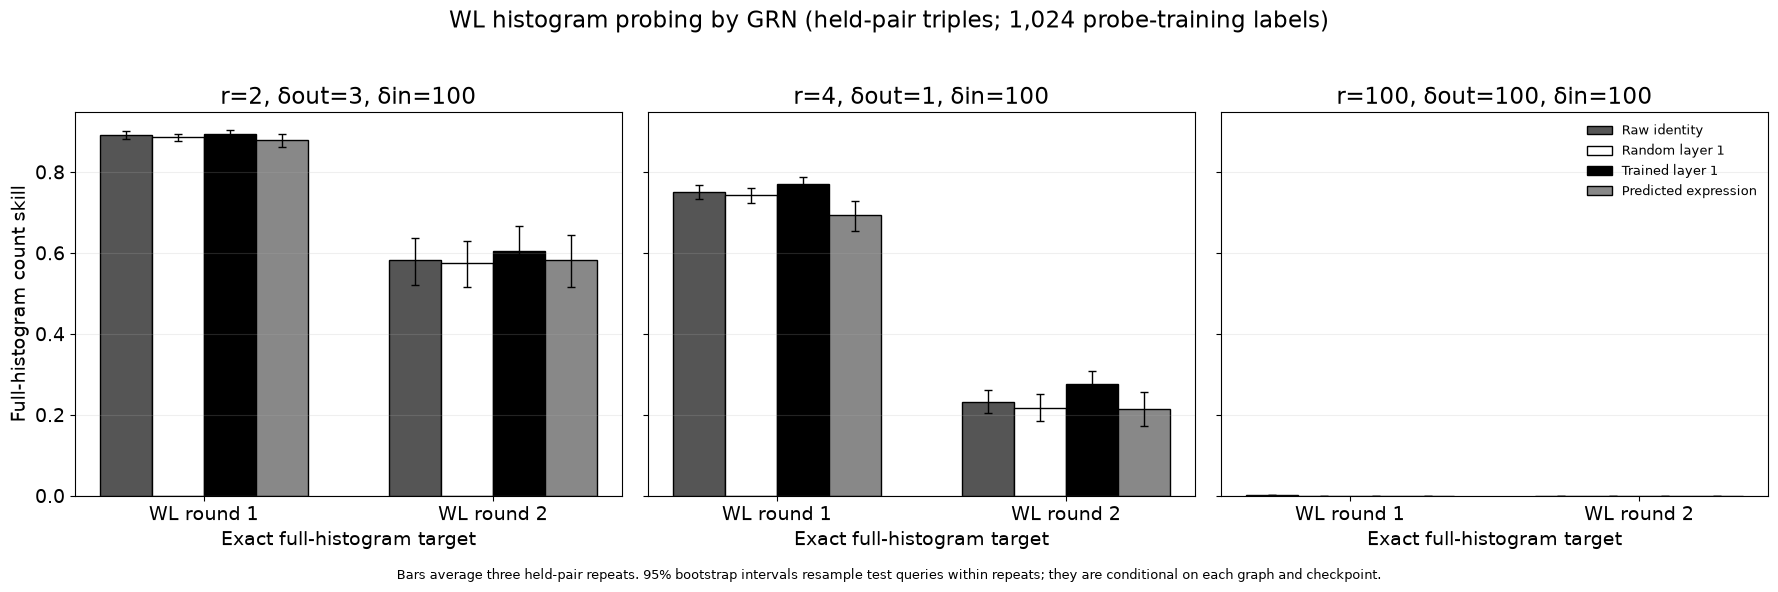

,GRN,WL view,representation,skill,CI low,CI high
0,"r=2, δout=3, δin=100",round1_counts,raw_input,0.8912,0.8806,0.9005
1,"r=2, δout=3, δin=100",round1_counts,random_h1,0.8853,0.8751,0.8941
2,"r=2, δout=3, δin=100",round1_counts,trained_h1,0.8937,0.8838,0.9025
3,"r=2, δout=3, δin=100",round1_counts,predicted_expression,0.8792,0.8617,0.8927
4,"r=2, δout=3, δin=100",round2_counts,raw_input,0.5816,0.5213,0.6367
5,"r=2, δout=3, δin=100",round2_counts,random_h1,0.5755,0.5158,0.6293
6,"r=2, δout=3, δin=100",round2_counts,trained_h1,0.6038,0.5401,0.6659
7,"r=2, δout=3, δin=100",round2_counts,predicted_expression,0.5831,0.5153,0.6446
8,"r=4, δout=1, δin=100",round1_counts,raw_input,0.7509,0.7331,0.7680
9,"r=4, δout=1, δin=100",round1_counts,random_h1,0.7433,0.7237,0.7608


In [31]:
# Exact directed/signed WL probes for G, G3, and G2.
# Requires the earlier MLP cell to have run, defining grn_configs and best_models.

from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from scipy import sparse


# Match the earlier WL comparison protocol.
WL_SEEDS = (11, 22, 33)
WL_N_QUERIES = 12_000
WL_N_TRAIN = 1_024
WL_N_VAL = 256
WL_N_TEST = 512
WL_BOOTSTRAPS = 2_000
WL_ALPHAS = (0.01, 0.1, 1, 10, 100, 1_000, 10_000, 1e6, 1e8, np.inf)


def sample_triples(n, count, seed):
    """Sample distinct, sorted triples without building the full combination set."""
    rng = np.random.default_rng(seed)
    seen, rows = set(), []
    while len(rows) < count:
        row = tuple(sorted(rng.choice(n, 3, replace=False).tolist()))
        if row not in seen:
            seen.add(row)
            rows.append(row)
    return np.asarray(rows, dtype=np.int32)


def held_pair_split(sets, n, seed):
    """Hold out pairs so no validation/test pair occurs in probe training."""
    rng = np.random.default_rng(seed)
    all_pairs = np.asarray(list(combinations(range(n), 2)), dtype=np.int32)
    order = rng.permutation(len(all_pairs))
    n_held = int(0.10 * len(all_pairs))

    val_pairs = {tuple(x) for x in all_pairs[order[:n_held]]}
    test_pairs = {
        tuple(x) for x in all_pairs[order[n_held:2 * n_held]]
    }

    touches_val = np.zeros(len(sets), dtype=bool)
    touches_test = np.zeros(len(sets), dtype=bool)
    for i, genes in enumerate(sets):
        pairs = list(combinations(map(int, genes), 2))
        touches_val[i] = any(pair in val_pairs for pair in pairs)
        touches_test[i] = any(pair in test_pairs for pair in pairs)

    train_pool = np.flatnonzero(~touches_val & ~touches_test)
    val_pool = np.flatnonzero(touches_val & ~touches_test)
    test_pool = np.flatnonzero(touches_test & ~touches_val)

    def take(pool, count, name):
        if len(pool) < count:
            raise ValueError(
                f"Not enough {name} triples: {len(pool)} available, "
                f"{count} needed."
            )
        return rng.permutation(pool)[:count]

    return (
        take(train_pool, WL_N_TRAIN, "training"),
        take(val_pool, WL_N_VAL, "validation"),
        take(test_pool, WL_N_TEST, "test"),
    )


def wl_count_histograms(beta, sets):
    """
    Exact WL count histograms, rounds 0–2.

    Each triple's subgraph is induced by the perturbed genes and their
    immediate downstream neighbors. Node names are not used. Refinement
    keeps separate positive/negative incoming/outgoing neighbor multisets.
    """
    beta = np.asarray(beta, dtype=float).copy()
    np.fill_diagonal(beta, 0)
    n = len(beta)
    signs = np.sign(beta).astype(np.int8)
    out_neighbors = [np.flatnonzero(beta[u] != 0) for u in range(n)]

    # These maps give globally consistent pattern IDs within each WL round.
    color_maps = [{}, {}]
    next_color = [0, 0]
    row_parts = [[] for _ in range(3)]
    col_parts = [[] for _ in range(3)]
    value_parts = [[] for _ in range(3)]
    vocab_sizes = [2, 0, 0]  # Round 0: perturbed and unperturbed labels.

    for row_id, genes_array in enumerate(sets):
        perturbed = set(map(int, genes_array))
        nodes_set = set(perturbed)

        for u in perturbed:
            nodes_set.update(map(int, out_neighbors[u]))

        nodes = sorted(nodes_set)
        node_set = set(nodes)

        out_pos = {u: [] for u in nodes}
        out_neg = {u: [] for u in nodes}
        in_pos = {u: [] for u in nodes}
        in_neg = {u: [] for u in nodes}

        # Restrict signed directed edges to this induced subgraph.
        for u in nodes:
            for v_array in out_neighbors[u]:
                v = int(v_array)
                if v not in node_set:
                    continue
                if signs[u, v] > 0:
                    out_pos[u].append(v)
                    in_pos[v].append(u)
                else:
                    out_neg[u].append(v)
                    in_neg[v].append(u)

        labels = {u: (0 if u in perturbed else 1) for u in nodes}

        for round_id in range(3):
            ids, counts = np.unique(
                np.fromiter(labels.values(), dtype=np.int32),
                return_counts=True,
            )
            row_parts[round_id].extend([row_id] * len(ids))
            col_parts[round_id].extend(ids.tolist())
            value_parts[round_id].extend(counts.tolist())

            if round_id == 2:
                continue

            new_labels = {}
            color_map = color_maps[round_id]

            for u in nodes:
                signature = (
                    labels[u],
                    tuple(sorted(labels[v] for v in in_pos[u])),
                    tuple(sorted(labels[v] for v in in_neg[u])),
                    tuple(sorted(labels[v] for v in out_pos[u])),
                    tuple(sorted(labels[v] for v in out_neg[u])),
                )

                color = color_map.get(signature)
                if color is None:
                    color = next_color[round_id]
                    color_map[signature] = color
                    next_color[round_id] += 1
                new_labels[u] = color

            labels = new_labels
            vocab_sizes[round_id + 1] = next_color[round_id]

    return [
        sparse.csr_matrix(
            (
                np.asarray(value_parts[r], dtype=np.float64),
                (np.asarray(row_parts[r]), np.asarray(col_parts[r])),
            ),
            shape=(len(sets), vocab_sizes[r]),
        )
        for r in range(3)
    ]


def histogram_sse(alpha_matrix, y_train, y_eval, output_gram, output_mean_row):
    """Per-query full-histogram SSE, including test-only pattern coordinates."""
    n_train = y_train.shape[0]
    total = np.asarray(y_train.sum(axis=0)).ravel()
    mean_norm = float(total @ total) / (n_train * n_train)

    eval_norm = np.asarray(y_eval.multiply(y_eval).sum(axis=1)).ravel()
    eval_dot_mean = np.asarray(y_eval @ total).ravel() / n_train
    baseline = np.maximum(eval_norm - 2 * eval_dot_mean + mean_norm, 0)

    cross = (y_eval @ y_train.T).toarray()
    centered_cross = cross - output_mean_row[None, :]
    cross_term = np.sum(alpha_matrix * centered_cross, axis=1)
    prediction_norm = np.sum(
        (alpha_matrix @ output_gram) * alpha_matrix, axis=1
    )

    errors = baseline - 2 * cross_term + prediction_norm
    return np.maximum(errors, 0), baseline


def fit_wl_ridge_and_test_errors(x, y, train_idx, val_idx, test_idx):
    """Select ridge strength on validation queries and return held-out errors."""
    x = np.asarray(x, dtype=np.float64)
    x_mean = x[train_idx].mean(axis=0)
    x_scale = np.maximum(x[train_idx].std(axis=0), 1e-8)
    x = (x - x_mean) / x_scale

    x_train = x[train_idx]
    k_train = x_train @ x_train.T
    k_val = x[val_idx] @ x_train.T
    k_test = x[test_idx] @ x_train.T

    # Eigen decomposition speeds up evaluating the regularization grid.
    eigval, eigvec = np.linalg.eigh(k_train)
    eigval = np.maximum(eigval, 0)
    k_val_eig = k_val @ eigvec
    k_test_eig = k_test @ eigvec

    y_train = y[train_idx].tocsr()
    y_val = y[val_idx].tocsr()
    y_test = y[test_idx].tocsr()
    n_train = len(train_idx)

    output_gram = (y_train @ y_train.T).toarray()
    output_mean_row = output_gram.sum(axis=1) / n_train
    centered_output_gram = (
        output_gram
        - output_mean_row[:, None]
        - output_mean_row[None, :]
        + output_gram.sum() / (n_train ** 2)
    )

    total = np.asarray(y_train.sum(axis=0)).ravel()
    val_baseline = (
        np.asarray(y_val.multiply(y_val).sum(axis=1)).ravel()
        - 2 * np.asarray(y_val @ total).ravel() / n_train
        + (total @ total) / (n_train ** 2)
    )
    val_baseline = np.maximum(val_baseline, 0)

    best_alpha = np.inf
    best_val_loss = np.inf

    for alpha in WL_ALPHAS:
        if np.isinf(alpha):
            val_error = val_baseline.copy()
        else:
            a_val = (
                k_val_eig / (eigval + alpha)[None, :]
            ) @ eigvec.T
            val_error, _ = histogram_sse(
                a_val, y_train, y_val,
                centered_output_gram, output_mean_row,
            )

        val_loss = val_error.sum() / max(val_baseline.sum(), 1e-12)
        if val_loss < best_val_loss:
            best_alpha = alpha
            best_val_loss = val_loss

    if np.isinf(best_alpha):
        test_error = (
            np.asarray(y_test.multiply(y_test).sum(axis=1)).ravel()
            - 2 * np.asarray(y_test @ total).ravel() / n_train
            + (total @ total) / (n_train ** 2)
        )
        test_error = np.maximum(test_error, 0)
        test_baseline = test_error.copy()
    else:
        a_test = (
            k_test_eig / (eigval + best_alpha)[None, :]
        ) @ eigvec.T
        test_error, test_baseline = histogram_sse(
            a_test, y_train, y_test,
            centered_output_gram, output_mean_row,
        )

    return test_error, test_baseline, best_alpha


def bootstrap_skill_ci(repeats, seed, n_boot=WL_BOOTSTRAPS):
    """Average per-split skill and query-bootstrap 95% confidence interval."""
    point = np.mean([
        1 - error.sum() / max(baseline.sum(), 1e-12)
        for error, baseline, _ in repeats
    ])

    rng = np.random.default_rng(seed)
    bootstrap_scores = np.empty(n_boot)

    for b in range(n_boot):
        split_scores = []
        for error, baseline, _ in repeats:
            ix = rng.integers(0, len(error), size=len(error))
            score = 1 - error[ix].sum() / max(baseline[ix].sum(), 1e-12)
            split_scores.append(score)
        bootstrap_scores[b] = np.mean(split_scores)

    low, high = np.quantile(bootstrap_scores, [0.025, 0.975])
    return point, low, high


# The notebook's existing grn_configs contains (label, network, singles, doubles).
# Using net.beta here directly accesses G.beta, G3.beta, and G2.beta.
wl_results = {}

for label, net, single, double in grn_configs:
    beta = np.asarray(net.beta, dtype=float)
    n = int(net.n)

    if beta.shape != (n, n):
        raise ValueError(
            f"{label}: net.beta has shape {beta.shape}; expected {(n, n)}."
        )

    model = best_models[label].to(torch.device("cpu")).eval()
    reps_by_view = {
        view: {
            rep: []
            for rep in (
                "raw_input", "random_h1",
                "trained_h1", "predicted_expression",
            )
        }
        for view in ("round1_counts", "round2_counts")
    }

    for seed in WL_SEEDS:
        print(f"{label}: WL split seed {seed}", flush=True)

        pool = sample_triples(n, WL_N_QUERIES, seed + 300)
        train_pool, val_pool, test_pool = held_pair_split(pool, n, seed)

        chosen = np.concatenate([
            train_pool[:WL_N_TRAIN],
            val_pool[:WL_N_VAL],
            test_pool[:WL_N_TEST],
        ])
        sets = pool[chosen]

        train_idx = np.arange(WL_N_TRAIN)
        val_idx = np.arange(WL_N_TRAIN, WL_N_TRAIN + WL_N_VAL)
        test_idx = np.arange(WL_N_TRAIN + WL_N_VAL, len(sets))

        y_rounds = wl_count_histograms(beta, sets)

        # Raw perturbation identities are multi-hot vectors.
        u = np.zeros((len(sets), n), dtype=np.float32)
        u[np.arange(len(sets))[:, None], sets] = 1.0
        u_tensor = torch.as_tensor(u, dtype=torch.float32)

        with torch.inference_mode():
            trained_h1 = model[:2](u_tensor).cpu().numpy()
            predicted_expression = model(u_tensor).cpu().numpy()

        # Same architecture, freshly initialized and left untrained.
        with torch.random.fork_rng(devices=[]):
            torch.manual_seed(seed + 10_000)
            random_model = nn.Sequential(
                nn.Linear(n, 512), nn.GELU(),
                nn.Linear(512, 512), nn.GELU(),
                nn.Linear(512, n),
            ).cpu().eval()

        with torch.inference_mode():
            random_h1 = random_model[:2](u_tensor).cpu().numpy()

        representations = {
            "raw_input": u,
            "random_h1": random_h1,
            "trained_h1": trained_h1,
            "predicted_expression": predicted_expression,
        }

        for view, round_id in (
            ("round1_counts", 1),
            ("round2_counts", 2),
        ):
            y = y_rounds[round_id]

            for rep, x in representations.items():
                error, baseline, alpha = fit_wl_ridge_and_test_errors(
                    x, y, train_idx, val_idx, test_idx
                )
                reps_by_view[view][rep].append((error, baseline, alpha))

    wl_results[label] = reps_by_view


# Plot the two refined WL rounds for each GRN, with query-bootstrap 95% CIs.
representations = (
    ("raw_input", "Raw identity", "#555555"),
    ("random_h1", "Random layer 1", "white"),
    ("trained_h1", "Trained layer 1", "black"),
    ("predicted_expression", "Predicted expression", "#888888"),
)
views = ("round1_counts", "round2_counts")
view_labels = ("WL round 1", "WL round 2")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
bar_width = 0.18
offsets = np.linspace(-1.5 * bar_width, 1.5 * bar_width, len(representations))
summary_rows = []

for ax, (label, net, single, double) in zip(axes, grn_configs):
    for round_index, (view, view_label) in enumerate(zip(views, view_labels)):
        for rep_index, (rep, rep_label, color) in enumerate(representations):
            point, low, high = bootstrap_skill_ci(
                wl_results[label][view][rep],
                seed=50_000 + round_index * 100 + rep_index,
            )

            ax.bar(
                round_index + offsets[rep_index],
                point,
                width=bar_width,
                color=color,
                label=rep_label if round_index == 0 else None,
                yerr=np.array([[
                    max(point - low, 0)
                ], [
                    max(high - point, 0)
                ]]),
                capsize=3,
                error_kw={"linewidth": 1},
                edgecolor='black'
            )

            summary_rows.append({
                "GRN": label,
                "WL view": view,
                "representation": rep,
                "skill": point,
                "CI low": low,
                "CI high": high,
            })

    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xticks([0, 1], view_labels)
    ax.set_title(label)
    ax.set_xlabel("Exact full-histogram target")
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("Full-histogram count skill")
axes[-1].legend(frameon=False, fontsize=9, loc="best")

fig.suptitle(
    "WL histogram probing by GRN "
    "(held-pair triples; 1,024 probe-training labels)",
    y=1.02,
)
fig.text(
    0.5, -0.015,
    "Bars average three held-pair repeats. "
    "95% bootstrap intervals resample test queries within repeats; "
    "they are conditional on each graph and checkpoint.",
    ha="center",
    fontsize=9,
)
fig.tight_layout()
fig.savefig("WL_probe_three_GRNs.png", dpi=300, bbox_inches="tight")
plt.show()

wl_summary_df = pd.DataFrame(summary_rows)
display(wl_summary_df.round(4))

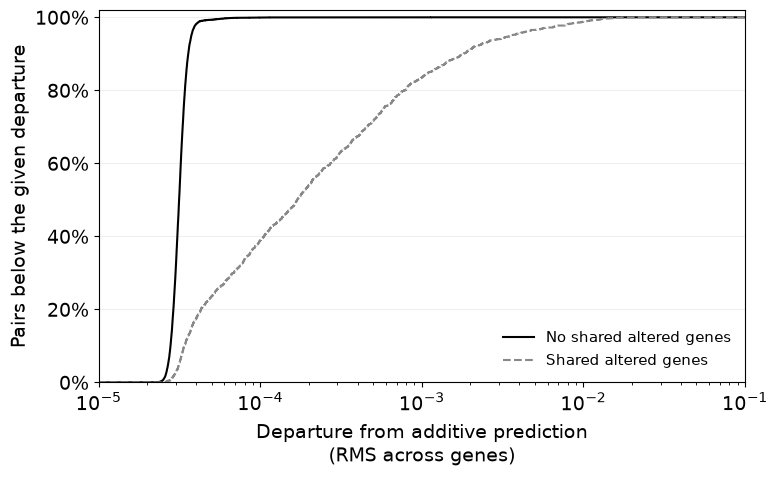

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from matplotlib.ticker import PercentFormatter

effect_threshold = 0.001

wt = np.asarray(G.rna, dtype=np.float64).reshape(-1)
single = np.asarray(single_ko_expression, dtype=np.float64)
double = np.asarray(double_expression, dtype=np.float64)
pair_ids = np.asarray(list(combinations(range(G.n), 2)))

changed = np.abs(single - wt) >= effect_threshold
overlap = (
    changed[pair_ids[:, 0]] & changed[pair_ids[:, 1]]
).any(axis=1)

additive = single[pair_ids[:, 0]] + single[pair_ids[:, 1]] - wt
departure = np.sqrt(np.mean((double - additive) ** 2, axis=1))

# Same training split as the original panel C.
order = np.random.default_rng(42).permutation(len(pair_ids))
train = order[int(0.5 * len(order)) + int(0.1 * len(order)):]

departure = departure[train]
overlap = overlap[train]

with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 14,
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
}):
    fig, ax = plt.subplots(figsize=(8, 5))

    for mask, color, linestyle, label in [
        (~overlap, "black", "-", "No shared altered genes"),
        (overlap, "#888888", "--", "Shared altered genes"),
    ]:
        values = np.sort(departure[mask])
        if not values.size:
            continue

        # Retain zero departures at the left edge of the log axis.
        values = np.maximum(values, 1e-5)
        cumulative = 100 * np.arange(1, len(values) + 1) / len(values)

        ax.step(
            np.r_[1e-5, values, max(0.1, values[-1])],
            np.r_[0, cumulative, 100],
            where="post",
            color=color,
            linestyle=linestyle,
            linewidth=1.5,
            label=label,
        )

    ax.set_xscale("log")
    ax.set_xlim(1e-5, 0.1)
    ax.set_ylim(0, 102)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

    ax.set_xlabel(
        "Departure from additive prediction\n"
        "(RMS across genes)"
    )
    ax.set_ylabel("Pairs below the given departure")
    ax.grid(axis="y", alpha=0.2)
    ax.legend(frameon=False, fontsize=11, loc="lower right")

    fig.tight_layout()
    fig.savefig(
        "G_double_KO_additivity_CDF.png",
        dpi=600,
        bbox_inches="tight",
    )
    plt.show()